In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Functions

In [2]:
# thresholds from payload parsing
def get_tier(fltDebtorScore):
    if fltDebtorScore <= 0.0921:
        return 'A1'
    elif fltDebtorScore <= 0.1538:
        return 'A'
    elif fltDebtorScore <= 0.2170:
        return 'B'
    elif fltDebtorScore <= 0.2288:
        return 'C'
    elif fltDebtorScore <= 0.2473:
        return 'D'
    else:
        return 'Decline'

In [3]:
def distribtions_by_segment(df, str_df, str_col, bool_save=False, str_local_path=None):
    # get n
    int_n = df.shape[0]
    # ax
    fig, ax = plt.subplots(figsize=(9,5))
    # title
    str_title = f'ECNL Distributions of {str_df} Data by Segment (N = {int_n})'
    ax.set_title(str_title)
    # xlabel
    ax.set_xlabel(f'ECNL in {str_df} Data')

    # ch 13
    list_tmp = list(df[df['intopenbktype__app'].isin(['13.0'])][str_col])
    flt_mdn = np.median(list_tmp)
    sns.kdeplot(list_tmp, ax=ax, label=f'Ch 13 - Mdn = {flt_mdn:0.4f}')
    # bk
    list_tmp = list(df[df['intopenbktype__app'].isin(['7.0','13.0'])][str_col])
    flt_mdn = np.median(list_tmp)
    sns.kdeplot(list_tmp, ax=ax, label=f'BK - Mdn = {flt_mdn:0.4f}')
    # ch 7
    list_tmp = list(df[df['intopenbktype__app'].isin(['7.0'])][str_col])
    flt_mdn = np.median(list_tmp)
    sns.kdeplot(list_tmp, ax=ax, label=f'Ch 7 - Mdn = {flt_mdn:0.4f}')
    # all
    list_tmp = list(df[str_col])
    flt_mdn = np.median(list_tmp)
    sns.kdeplot(list_tmp, ax=ax, label=f'All - Mdn = {flt_mdn:0.4f}')
    # nobk
    list_tmp = list(df[df['intopenbktype__app'].isin(['nan'])][str_col])
    flt_mdn = np.median(list_tmp)
    sns.kdeplot(list_tmp, ax=ax, label=f'No BK - Mdn = {flt_mdn:0.4f}')

    # legend
    plt.legend()
    
    # save
    if bool_save:
        plt.savefig(str_local_path, bbox_inches='tight')
    
    # plot
    plt.show()

In [4]:
def distributions_by_df(ser_test, ser_prod, str_subset):
    # ax
    fig, ax = plt.subplots(figsize=(9,5))
    # title
    str_title = f'Distributions of ECNL in Test Data and Production Data ({str_subset})'
    ax.set_title(str_title)
    # xlabel
    ax.set_xlabel('ECNL')
    # test
    list_tmp = list(ser_test)
    flt_mdn = np.median(list_tmp)
    sns.kdeplot(list_tmp, ax=ax, label=f'Test - Mdn = {flt_mdn:0.4f}')
    # prod
    list_tmp = list(ser_prod)
    flt_mdn = np.median(list_tmp)
    sns.kdeplot(list_tmp, ax=ax, label=f'Prod - Mdn = {flt_mdn:0.4f}')
    # legend
    plt.legend()
    # show
    plt.show()

In [5]:
def get_tier_test_prod(df_test, df_prod):
    # get tier prop test
    ser_freq = df_test['tier'].value_counts(normalize=True)
    df_freq_test = ser_freq.reset_index()
    df_freq_test.columns = ['Tier', 'Proportion Test']

    # get tier prop prod
    ser_freq = df_prod['tier'].value_counts(normalize=True)
    df_freq_prod = ser_freq.reset_index()
    df_freq_prod.columns = ['Tier', 'Proportion Production']

    # join
    df_tmp = pd.merge(
        left=df_freq_test,
        right=df_freq_prod,
        on='Tier',
        how='outer',
    )
    # get difference
    df_tmp['Prod - Test'] = df_tmp['Proportion Production'] - df_tmp['Proportion Test']
    # sort
    df_tmp.sort_values(by='Proportion Production', ascending=False, inplace=True)
    # return
    return df_tmp

### Constants

In [6]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_dirname_output = './output'
str_variant = 'noPTImodel10'

Project: 20231010-gen-xii


### Output dir

In [7]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant dir

In [8]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Import test data

In [9]:
str_filename = 'df.csv'
str_uri = f's3://{str_project}/08_retro_scoring/08_segment_distributions/01_gen_xii_test/{str_filename}'
df_test = pd.read_csv(str_uri)
df_test['tier'] = df_test['ECNL_test'].apply(get_tier)
df_test['intopenbktype__app'] = df_test['intopenbktype__app'].astype(str)
df_test

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/fsspec/registry.py:275: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


,bigaccountid__app,intopenbktype__app,yhat_pricing_pd,yhat_pricing_lgd,ECNL_test,tier
0,3932700.0,nan,0.167898,0.619272,0.245380,D
1,3932720.0,nan,0.151628,0.638730,0.228564,C
2,3932724.0,nan,0.168548,0.607942,0.241824,D
3,3932730.0,nan,0.578571,0.620471,0.847208,Decline
4,3932752.0,nan,0.366915,0.673531,0.583223,Decline
...,...,...,...,...,...,...
27802,4812483.0,7.0,0.103705,0.579950,0.141940,A
27803,4812497.0,nan,0.339801,0.597389,0.479065,Decline
27804,4812498.0,nan,0.152231,0.592475,0.212856,B
27805,4812503.0,7.0,0.159518,0.689688,0.259642,Decline


### Import production data

In [10]:
str_filename = 'df.csv'
str_uri = f's3://{str_project}/08_retro_scoring/08_segment_distributions/02_gen_xii_production/{str_filename}'
df_prod = pd.read_csv(str_uri)
df_prod['tier'] = df_prod['ECNL_production'].apply(get_tier)
df_prod['intopenbktype__app'] = df_prod['intopenbktype__app'].astype(str)
df_prod

,bigAccountId,intopenbktype__app,yhat_pricing_pd,yhat_pricing_lgd,ECNL_production,tier
0,5514485,nan,0.457796,0.637971,0.689263,Decline
1,5514970,nan,0.118641,0.649063,0.181733,B
2,5515245,nan,0.384922,0.643923,0.584950,Decline
3,5515340,nan,0.236593,0.640644,0.357709,Decline
4,5515580,nan,0.290466,0.629329,0.431404,Decline
...,...,...,...,...,...,...
58426,7373944,nan,0.177340,0.680696,0.284887,Decline
58427,7373949,nan,0.293760,0.627291,0.434884,Decline
58428,7373986,13.0,0.096083,0.647022,0.146717,A
58429,7374018,13.0,0.121283,0.669731,0.191695,B


### Test distributions

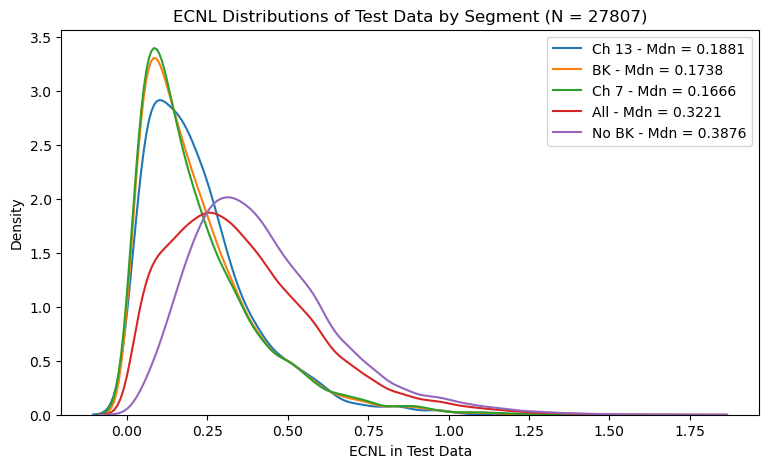

In [11]:
distribtions_by_segment(
    df=df_test, 
    str_df='Test', 
    str_col='ECNL_test',
)

### Production

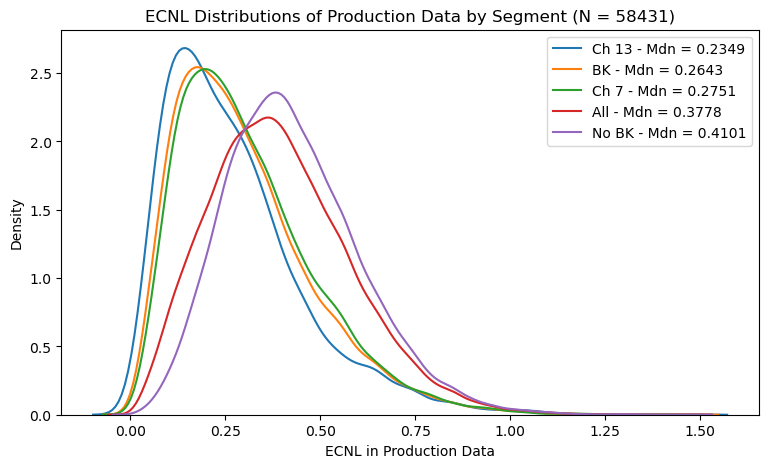

In [12]:
str_filename = 'plt_kde_prod.png'
distribtions_by_segment(
    df=df_prod, 
    str_df='Production', 
    str_col='ECNL_production',
    bool_save=True,
    str_local_path=f'{str_dirname_output}/{str_variant}/{str_filename}',
)

### Look at each segment between test and production

#### All

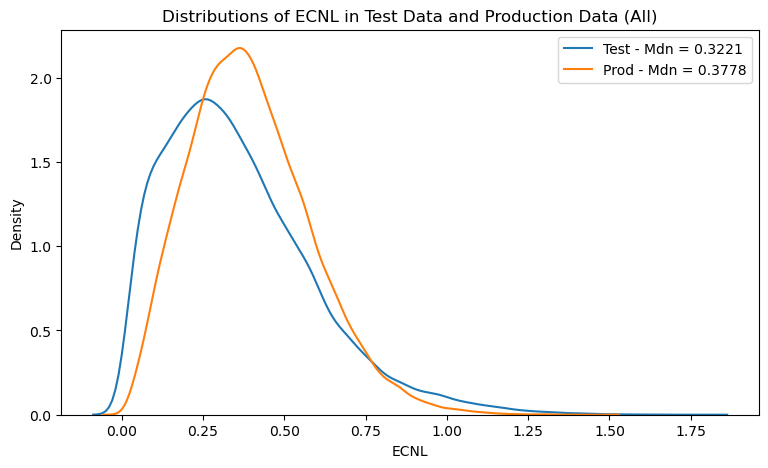

In [13]:
distributions_by_df(
    ser_test=df_test['ECNL_test'], 
    ser_prod=df_prod['ECNL_production'], 
    str_subset='All',
)

#### BK

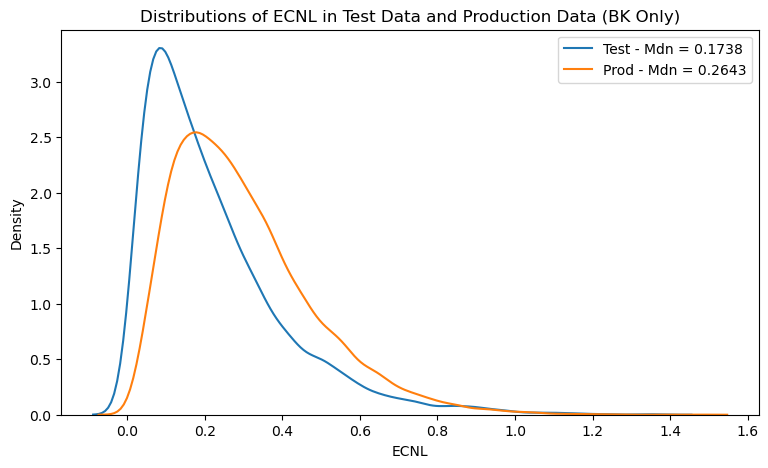

In [14]:
distributions_by_df(
    ser_test=df_test[df_test['intopenbktype__app'].isin(['7.0','13.0'])]['ECNL_test'], 
    ser_prod=df_prod[df_prod['intopenbktype__app'].isin(['7.0','13.0'])]['ECNL_production'], 
    str_subset='BK Only',
)

#### Ch 7

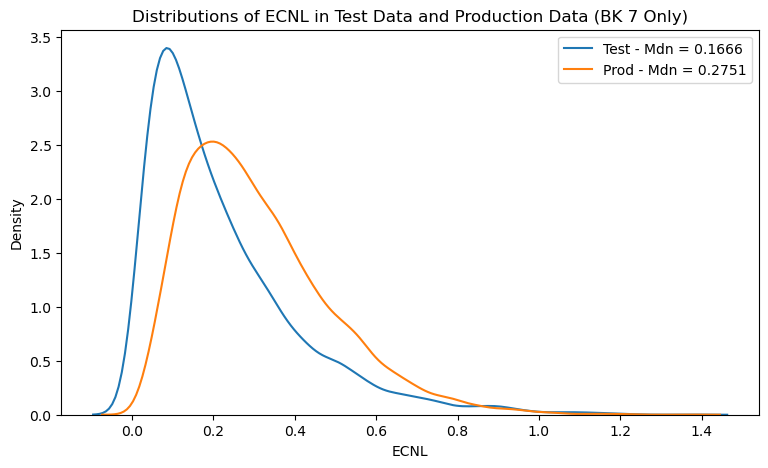

In [15]:
distributions_by_df(
    ser_test=df_test[df_test['intopenbktype__app'].isin(['7.0'])]['ECNL_test'], 
    ser_prod=df_prod[df_prod['intopenbktype__app'].isin(['7.0'])]['ECNL_production'], 
    str_subset='BK 7 Only',
)

#### Ch 13

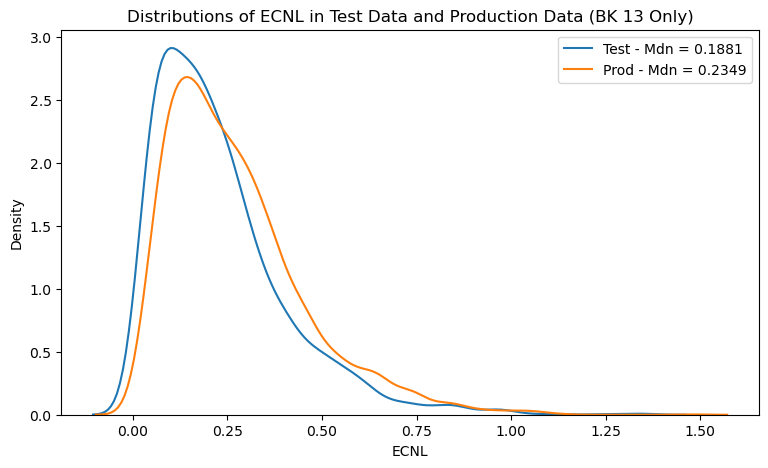

In [16]:
distributions_by_df(
    ser_test=df_test[df_test['intopenbktype__app'].isin(['13.0'])]['ECNL_test'], 
    ser_prod=df_prod[df_prod['intopenbktype__app'].isin(['13.0'])]['ECNL_production'], 
    str_subset='BK 13 Only',
)

#### No BK

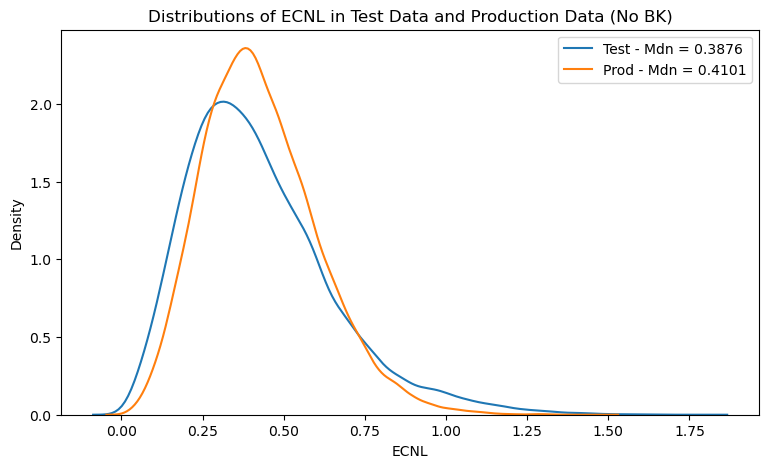

In [17]:
distributions_by_df(
    ser_test=df_test[df_test['intopenbktype__app'].isin(['nan'])]['ECNL_test'], 
    ser_prod=df_prod[df_prod['intopenbktype__app'].isin(['nan'])]['ECNL_production'], 
    str_subset='No BK',
)

### Tier distributions

#### All

In [18]:
df_tmp = get_tier_test_prod(
    df_test=df_test, 
    df_prod=df_prod,
)

df_tmp

,Tier,Proportion Test,Proportion Production,Prod - Test
5,Decline,0.638976,0.773716,0.134740
2,B,0.111231,0.088943,-0.022288
0,A,0.095803,0.058137,-0.037666
4,D,0.034272,0.033253,-0.001019
1,A1,0.097637,0.025860,-0.071778
3,C,0.022081,0.020092,-0.001989


#### Save for writeup

In [19]:
# save
list_cols = [
    'Tier',
    'Proportion Production',
]
df_tmp = df_tmp[list_cols].copy()

# save
str_filename = 'df_tier_dist.csv'
str_local_path = f'{str_dirname_output}/{str_variant}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)

# show
df_tmp

,Tier,Proportion Production
5,Decline,0.773716
2,B,0.088943
0,A,0.058137
4,D,0.033253
1,A1,0.025860
3,C,0.020092


#### BK

In [20]:
df_tmp = get_tier_test_prod(
    df_test=df_test[df_test['intopenbktype__app'].isin(['7.0','13.0'])], 
    df_prod=df_prod[df_prod['intopenbktype__app'].isin(['7.0','13.0'])],
)
df_tmp

,Tier,Proportion Test,Proportion Production,Prod - Test
5,Decline,0.339783,0.539985,0.200202
2,B,0.153786,0.161827,0.008041
0,A,0.188681,0.145995,-0.042687
1,A1,0.257689,0.078017,-0.179673
4,D,0.036797,0.044196,0.007399
3,C,0.023264,0.029980,0.006717


#### Ch 7

In [21]:
df_tmp = get_tier_test_prod(
    df_test=df_test[df_test['intopenbktype__app'].isin(['7.0'])], 
    df_prod=df_prod[df_prod['intopenbktype__app'].isin(['7.0'])],
)
df_tmp

,Tier,Proportion Test,Proportion Production,Prod - Test
5,Decline,0.331551,0.566375,0.234824
2,B,0.146115,0.162074,0.015959
0,A,0.194243,0.136567,-0.057677
1,A1,0.271312,0.060510,-0.210802
4,D,0.035074,0.043753,0.008680
3,C,0.021705,0.030721,0.009016


#### Ch 13

In [22]:
df_tmp = get_tier_test_prod(
    df_test=df_test[df_test['intopenbktype__app'].isin(['13.0'])], 
    df_prod=df_prod[df_prod['intopenbktype__app'].isin(['13.0'])],
)
df_tmp

,Tier,Proportion Test,Proportion Production,Prod - Test
5,Decline,0.360046,0.470861,0.110814
0,A,0.174990,0.170690,-0.004300
2,B,0.172667,0.161180,-0.011487
1,A1,0.224158,0.123872,-0.100286
4,D,0.041038,0.045355,0.004317
3,C,0.027100,0.028042,0.000942


#### No BK

In [23]:
df_tmp = get_tier_test_prod(
    df_test=df_test[df_test['intopenbktype__app'].isin(['nan'])], 
    df_prod=df_prod[df_prod['intopenbktype__app'].isin(['nan'])],
)
df_tmp

,Tier,Proportion Test,Proportion Production,Prod - Test
5,Decline,0.780770,0.853308,0.072539
2,B,0.091063,0.064123,-0.026940
4,D,0.033075,0.029526,-0.003549
0,A,0.051786,0.028219,-0.023568
3,C,0.021520,0.016725,-0.004795
1,A1,0.021785,0.008099,-0.013687
